#**AML LAB**

##**AML MINI PROJECT**

###1. INSTALL & IMPORT LIBRARIES

In [1]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Install XGBoost (Lab 6 & 8 — Credit Risk, Student Performance)
!pip install xgboost -q

# Visualization
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
plt.style.use('seaborn-v0_8-whitegrid')
PALETTE = ['#2196F3', '#F44336', '#4CAF50', '#FF9800', '#9C27B0']

# Scikit-learn: Preprocessing
from sklearn.model_selection import (
    train_test_split, cross_val_score,
    StratifiedKFold, KFold
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline

# Scikit-learn: Regression Models
from sklearn.linear_model import (
    LinearRegression,
    Ridge,        # L2 Regularization
    Lasso,        # L1 Regularization
    RidgeCV,      # Ridge with built-in Cross Validation
    LassoCV,      # Lasso with built-in Cross Validation
    ElasticNet    # L1 + L2 combined (bonus comparison)
)

# Scikit-learn: Classification Models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# NEW — Additional Classification Models (from Lab experiments)
from sklearn.linear_model import SGDClassifier          # Lab 5 (SGD)
from sklearn.svm import LinearSVC                       # Lab 5 & 9 (SVM — fast linear variant)
from sklearn.calibration import CalibratedClassifierCV  # Wraps LinearSVC to enable predict_proba
from sklearn.neighbors import KNeighborsClassifier      # Lab 8, 9, 10 (KNN)
from sklearn.ensemble import BaggingClassifier          # Lab 11 (Ensemble — Bagging)
from sklearn.naive_bayes import GaussianNB              # Lab 5 (Naïve Bayes)
from xgboost import XGBClassifier                       # Lab 6 & 8 (XGBoost)

# Scikit-learn: Evaluation
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error,
    r2_score,
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    roc_curve, auc, roc_auc_score
)

print("  All libraries imported successfully.")

  All libraries imported successfully.


###2. LOAD DATASET

In [2]:
from google.colab import files
import io

print("Loading PaySim Dataset...")

df_raw = pd.read_csv('/content/PS_20174392719_1491204439457_log.csv')

print(f"\nRaw dataset shape : {df_raw.shape}")
print(f"Columns           : {list(df_raw.columns)}")
print(f"\nTransaction types :\n{df_raw['type'].value_counts().to_string()}")
print(f"\nFraud distribution:\n{df_raw['isFraud'].value_counts().to_string()}")
print(f"\nMissing values    : {df_raw.isnull().sum().sum()}")
print("\nFirst 5 rows:")
df_raw.head()


Loading PaySim Dataset...

Raw dataset shape : (1186322, 11)
Columns           : ['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']

Transaction types :
type
CASH_OUT    420022
PAYMENT     401819
CASH_IN     258005
TRANSFER     98314
DEBIT         8162

Fraud distribution:
isFraud
0.0    1184807
1.0       1514

Missing values    : 4

First 5 rows:


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,0.0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1.0,0.0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1.0,0.0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0.0,0.0


###3. EXPLORATORY DATA ANALYSIS (EDA)

  BLOCK 3: EXPLORATORY DATA ANALYSIS

3.1 DATASET STRUCTURE
Shape  : 1,186,322 rows × 11 columns
Nulls  : 4

Statistical Summary (numeric columns):


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,1.186322e+06,1.186322e+06,1.186322e+06,1.186322e+06,1.186321e+06,1.186321e+06,1.186321e+06,1186321.0
mean,3.857310e+01,1.616763e+05,8.753993e+05,8.954893e+05,9.812116e+05,1.115171e+06,1.276214e-03,0.0
std,3.538631e+01,2.745069e+05,2.969945e+06,3.006369e+06,2.302363e+06,2.418507e+06,3.570136e-02,0.0
min,1.000000e+00,1.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0
25%,1.500000e+01,1.237520e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0
50%,3.300000e+01,7.687768e+04,1.580200e+04,0.000000e+00,1.256429e+05,2.180611e+05,0.000000e+00,0.0
75%,4.200000e+01,2.162486e+05,1.328108e+05,1.719783e+05,9.209185e+05,1.151312e+06,0.000000e+00,0.0
max,1.320000e+02,1.000000e+07,3.893942e+07,3.894623e+07,4.216916e+07,4.220740e+07,1.000000e+00,0.0


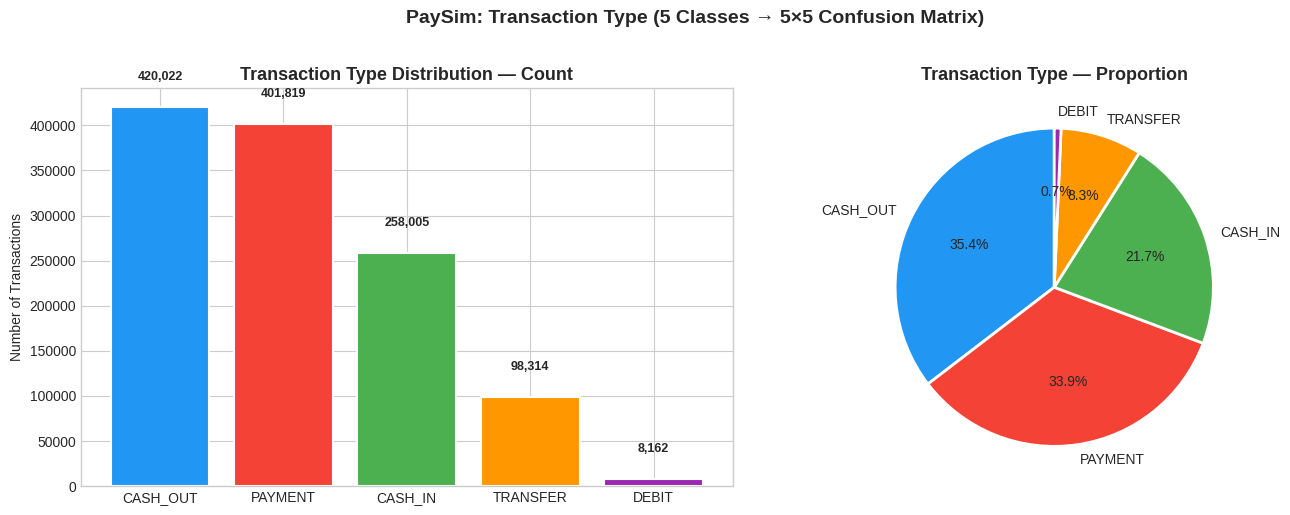

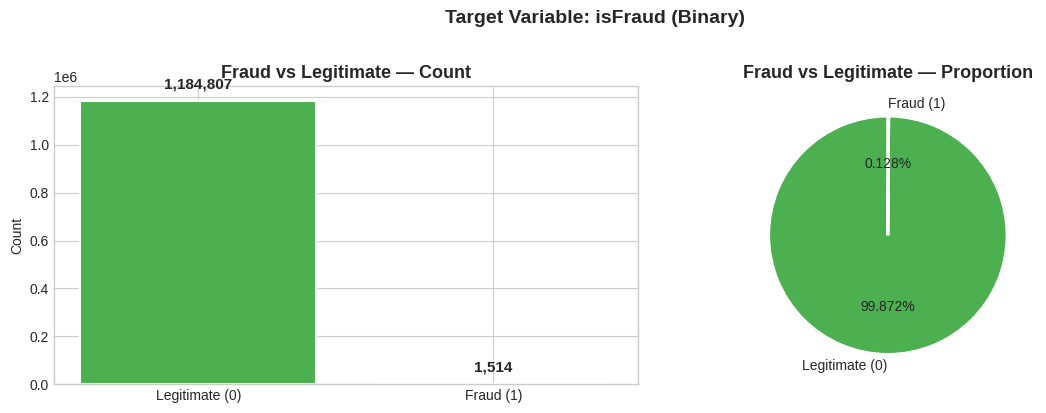

Fraud ratio: 1,514 fraud / 1,184,807 legit = 0.128%


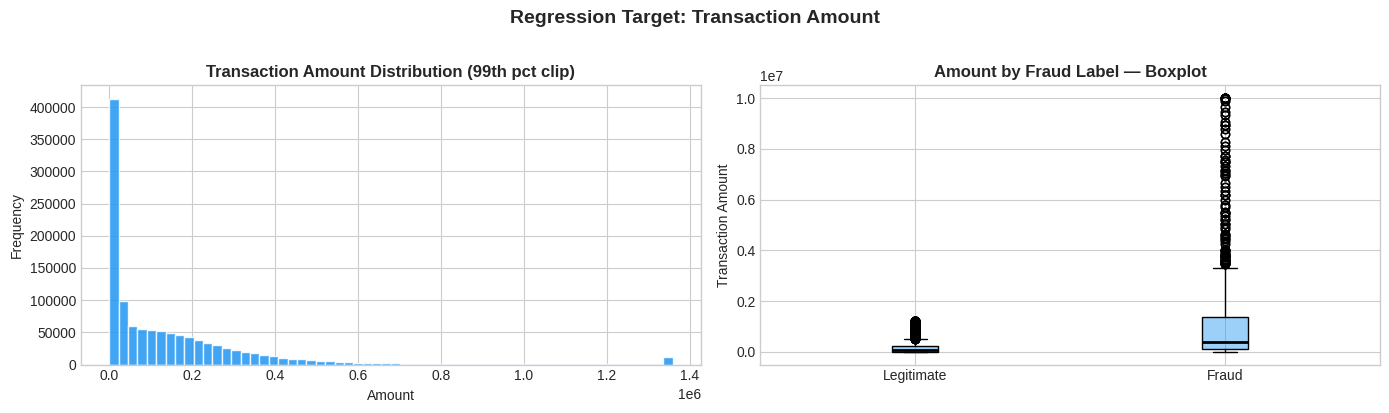


3.5 Fraud Rate by Transaction Type:
            sum   count      rate
type                             
CASH_IN     0.0  258005  0.000000
CASH_OUT  764.0  420021  0.181896
DEBIT       0.0    8162  0.000000
PAYMENT     0.0  401819  0.000000
TRANSFER  750.0   98314  0.762862


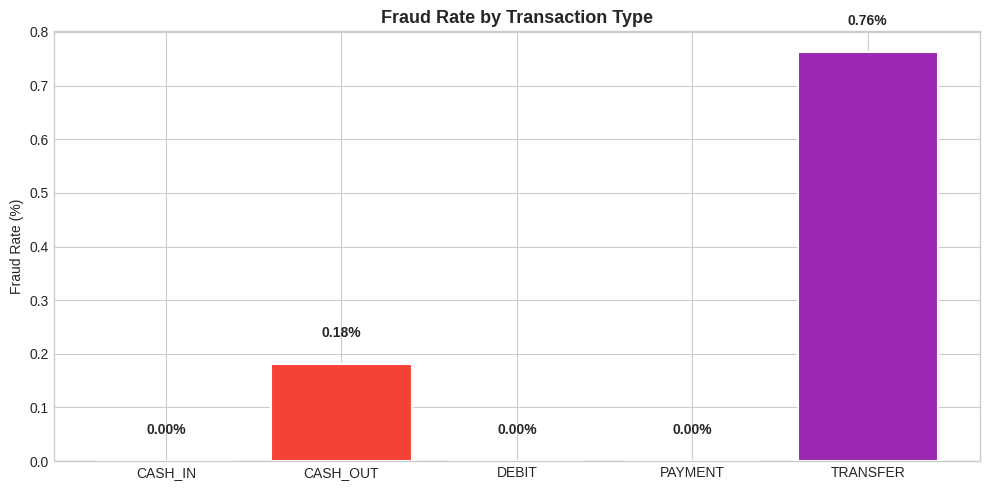

In [3]:
print("  BLOCK 3: EXPLORATORY DATA ANALYSIS")

# 3.1 Dataset Structure
print("\n3.1 DATASET STRUCTURE")
print(f"Shape  : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print(f"Nulls  : {df_raw.isnull().sum().sum()}")
print("\nStatistical Summary (numeric columns):")
display(df_raw.describe())

# 3.2 Transaction Type Distribution (5 classes → 5×5 confusion matrix)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

type_counts = df_raw['type'].value_counts()
colors_type = ['#2196F3','#F44336','#4CAF50','#FF9800','#9C27B0']
axes[0].bar(type_counts.index, type_counts.values,
            color=colors_type, edgecolor='white', linewidth=1.5)
axes[0].set_title('Transaction Type Distribution — Count', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Transactions')
for i, v in enumerate(type_counts.values):
    axes[0].text(i, v + 30000, f'{v:,}', ha='center', fontweight='bold', fontsize=9)

axes[1].pie(type_counts.values, labels=type_counts.index,
            autopct='%1.1f%%', colors=colors_type,
            startangle=90, wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Transaction Type — Proportion', fontsize=13, fontweight='bold')

plt.suptitle('PaySim: Transaction Type (5 Classes → 5×5 Confusion Matrix)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('type_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# 3.3 Fraud vs Legitimate Distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fraud_counts = df_raw['isFraud'].value_counts()
labels_fraud = ['Legitimate (0)', 'Fraud (1)']

axes[0].bar(labels_fraud, fraud_counts.values,
            color=['#4CAF50','#F44336'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Fraud vs Legitimate — Count', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(fraud_counts.values):
    axes[0].text(i, v + 50000, f'{v:,}', ha='center', fontweight='bold', fontsize=11)

axes[1].pie(fraud_counts.values, labels=labels_fraud,
            autopct='%1.3f%%', colors=['#4CAF50','#F44336'],
            startangle=90, wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Fraud vs Legitimate — Proportion', fontsize=13, fontweight='bold')

plt.suptitle('Target Variable: isFraud (Binary)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fraud_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Fraud ratio: {fraud_counts[1]:,} fraud / {fraud_counts[0]:,} legit = {fraud_counts[1]/fraud_counts[0]*100:.3f}%")

# 3.4 Amount Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
amount_clip = df_raw['amount'].clip(upper=df_raw['amount'].quantile(0.99))
axes[0].hist(amount_clip, bins=60, color='#2196F3', edgecolor='white', alpha=0.85)
axes[0].set_title('Transaction Amount Distribution (99th pct clip)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Amount')
axes[0].set_ylabel('Frequency')

fraud_amounts = df_raw[df_raw['isFraud']==1]['amount']
legit_amounts = df_raw[df_raw['isFraud']==0]['amount'].sample(len(fraud_amounts)*3, random_state=42)
axes[1].boxplot([legit_amounts.clip(upper=legit_amounts.quantile(0.99)),
                 fraud_amounts.clip(upper=fraud_amounts.quantile(0.99))],
                labels=['Legitimate','Fraud'], patch_artist=True,
                boxprops=dict(facecolor='#2196F370'),
                medianprops=dict(color='black', linewidth=2))
axes[1].set_title('Amount by Fraud Label — Boxplot', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Transaction Amount')

plt.suptitle('Regression Target: Transaction Amount', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('amount_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# 3.5 Fraud by Transaction Type
fraud_by_type = df_raw.groupby('type')['isFraud'].agg(['sum','count'])
fraud_by_type['rate'] = fraud_by_type['sum'] / fraud_by_type['count'] * 100
print("\n3.5 Fraud Rate by Transaction Type:")
print(fraud_by_type.to_string())

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(fraud_by_type.index, fraud_by_type['rate'],
              color=colors_type, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, fraud_by_type['rate']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{val:.2f}%', ha='center', fontweight='bold', fontsize=10)
ax.set_title('Fraud Rate by Transaction Type', fontsize=13, fontweight='bold')
ax.set_ylabel('Fraud Rate (%)')
plt.tight_layout()
plt.savefig('fraud_by_type.png', dpi=150, bbox_inches='tight')
plt.show()


###4. DATA PREPROCESSING

In [4]:
print("  BLOCK 4: DATA PREPROCESSING")

# ── 4.1 Sample for speed — 50k rows stratified by type ───────────────────
df = df_raw.groupby('type', group_keys=False).apply(
    lambda x: x.sample(min(len(x), 10000), random_state=42)
).reset_index(drop=True)

print(f"Sampled dataset shape: {df.shape}")
print(f"Type distribution after sampling:\n{df['type'].value_counts().to_string()}")

# ── 4.2 Feature Engineering ──────────────────────────────────────────────
df['balanceOrigDiff'] = df['newbalanceOrig'] - df['oldbalanceOrg']
df['balanceDestDiff'] = df['newbalanceDest'] - df['oldbalanceDest']
df['origBalanceZero'] = (df['oldbalanceOrg'] == 0).astype(int)
df['destBalanceZero'] = (df['oldbalanceDest'] == 0).astype(int)
df['amountLog']       = np.log1p(df['amount'])
df['surplusOrig']     = df['oldbalanceOrg'] - df['amount']

print("\nEngineered features added.")

# ── 4.3 Encode transaction type ──────────────────────────────────────────
le_type = LabelEncoder()
df['type_encoded'] = le_type.fit_transform(df['type'])
type_class_map = dict(zip(le_type.classes_, le_type.transform(le_type.classes_)))
print(f"\ntype → encoded mapping: {type_class_map}")

# ── 4.4 Feature columns ──────────────────────────────────────────────────
feature_cols = [
    'step', 'amount', 'oldbalanceOrg', 'newbalanceOrig',
    'oldbalanceDest', 'newbalanceDest',
    'balanceOrigDiff', 'balanceDestDiff',
    'origBalanceZero', 'destBalanceZero',
    'amountLog', 'surplusOrig', 'isFlaggedFraud'
]

# ── REGRESSION: predict log(amount) ──────────────────────────────────────
print("\n4.1 PREPROCESSING — REGRESSION DATASET")

# FIX: exclude 'amount' (raw target), 'amountLog' (IS the target — data leakage),
#      and 'surplusOrig' (= oldbalanceOrg - amount, directly encodes amount — leakage)
reg_feature_cols  = [c for c in feature_cols if c not in ['amount', 'amountLog', 'surplusOrig']]
reg_feature_names = reg_feature_cols

print(f"Regression features used ({len(reg_feature_cols)}): {reg_feature_cols}")
print("Excluded — 'amountLog' (is the target), 'surplusOrig' (encodes amount directly)")

X_reg = df[reg_feature_cols].copy()
y_reg = df['amountLog']

scaler_reg = StandardScaler()
X_reg_scaled = scaler_reg.fit_transform(X_reg)
X_reg_scaled = pd.DataFrame(X_reg_scaled, columns=reg_feature_cols)

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg_scaled, y_reg, test_size=0.20, random_state=42
)
print(f"Feature matrix X : {X_reg.shape}")
print(f"Train: {X_reg_train.shape[0]}  |  Test: {X_reg_test.shape[0]}")

# ── CLASSIFICATION: predict transaction type (5 classes → 5×5 CM) ────────
print("\n4.2 PREPROCESSING — CLASSIFICATION DATASET (5-class)")
clf_feature_cols = [c for c in feature_cols if c not in ['amount', 'amountLog']]

X_clf = df[clf_feature_cols].copy()
y_clf = df['type_encoded']

scaler_clf = StandardScaler()
X_clf_scaled = scaler_clf.fit_transform(X_clf)
X_clf_scaled = pd.DataFrame(X_clf_scaled, columns=clf_feature_cols)

X_clf_train, X_clf_test, y_clf_train, y_clf_test = train_test_split(
    X_clf_scaled, y_clf, test_size=0.20, random_state=42, stratify=y_clf
)
print(f"Feature matrix X : {X_clf.shape}")
print(f"Classes: {list(le_type.classes_)}")
print(f"Train: {X_clf_train.shape[0]}  |  Test: {X_clf_test.shape[0]}")
print("\nPreprocessing complete.")

  BLOCK 4: DATA PREPROCESSING
Sampled dataset shape: (48162, 11)
Type distribution after sampling:
type
CASH_IN     10000
CASH_OUT    10000
PAYMENT     10000
TRANSFER    10000
DEBIT        8162

Engineered features added.

type → encoded mapping: {'CASH_IN': np.int64(0), 'CASH_OUT': np.int64(1), 'DEBIT': np.int64(2), 'PAYMENT': np.int64(3), 'TRANSFER': np.int64(4)}

4.1 PREPROCESSING — REGRESSION DATASET
Regression features used (10): ['step', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'balanceOrigDiff', 'balanceDestDiff', 'origBalanceZero', 'destBalanceZero', 'isFlaggedFraud']
Excluded — 'amountLog' (is the target), 'surplusOrig' (encodes amount directly)
Feature matrix X : (48162, 10)
Train: 38529  |  Test: 9633

4.2 PREPROCESSING — CLASSIFICATION DATASET (5-class)
Feature matrix X : (48162, 11)
Classes: ['CASH_IN', 'CASH_OUT', 'DEBIT', 'PAYMENT', 'TRANSFER']
Train: 38529  |  Test: 9633

Preprocessing complete.


###5. THE CORE — L1 vs L2 EFFECT DEMONSTRATION
###(Before regularization → Overfitting | After → Fixed)
###This is what the project is fundamentally about

  CORE CONCEPT: WHY REGULARIZATION?
  Demonstrating Overfitting vs Regularized Models on PaySim

Linear Regression (NO regularization):
  Train R² = 0.2145  |  Test R² = 0.2377
  Gap (Overfit indicator) = -0.0232
  Largest 3 coefficients: [np.float64(0.6940907332649003), np.float64(0.4319308120237363), np.float64(0.20397915499939986)]

Lasso Regression (L1, alpha=0.05):
  Train R² = 0.2113  |  Test R² = 0.2308
  Coefficients driven to ZERO: 3 / 10
  → L1 performs automatic feature selection!

Ridge Regression (L2, alpha=1.0):
  Train R² = 0.2145  |  Test R² = 0.2377
  → L2 shrinks ALL coefficients but keeps all features.


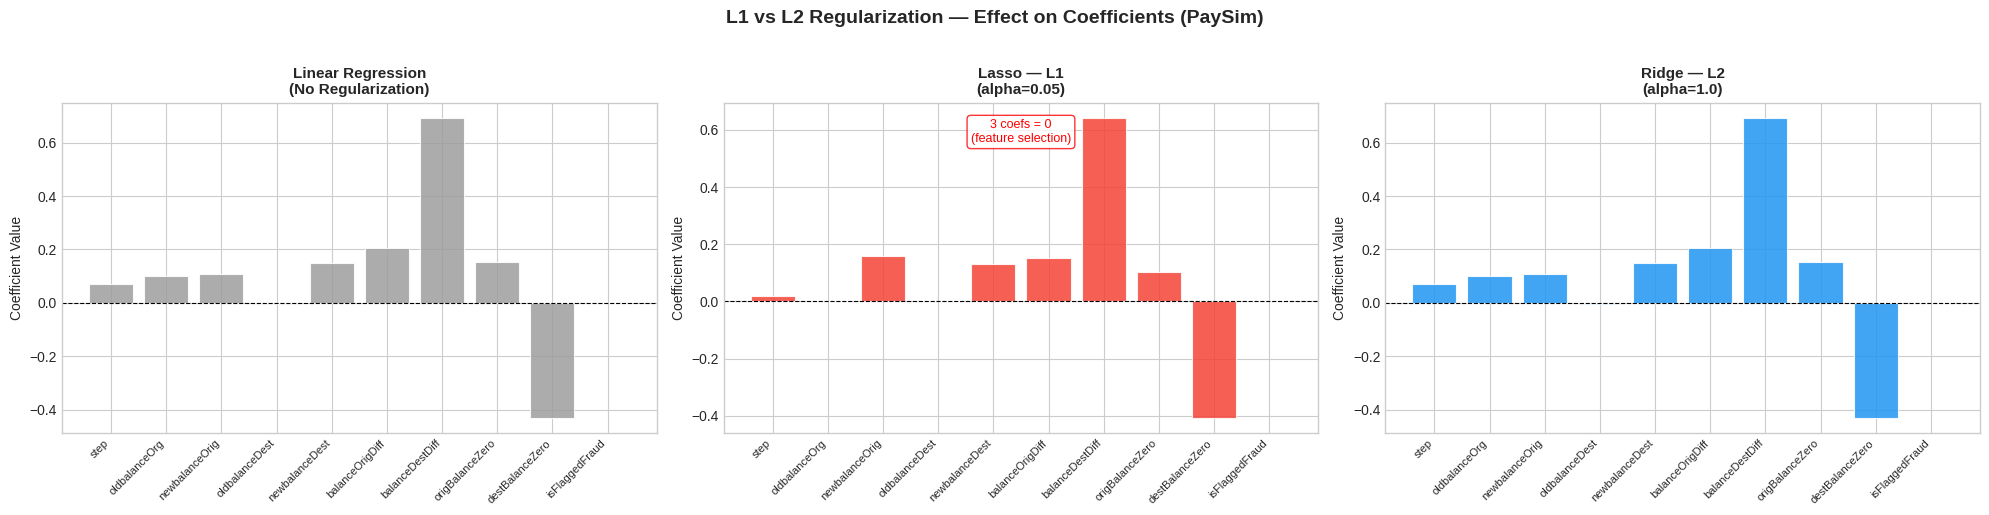

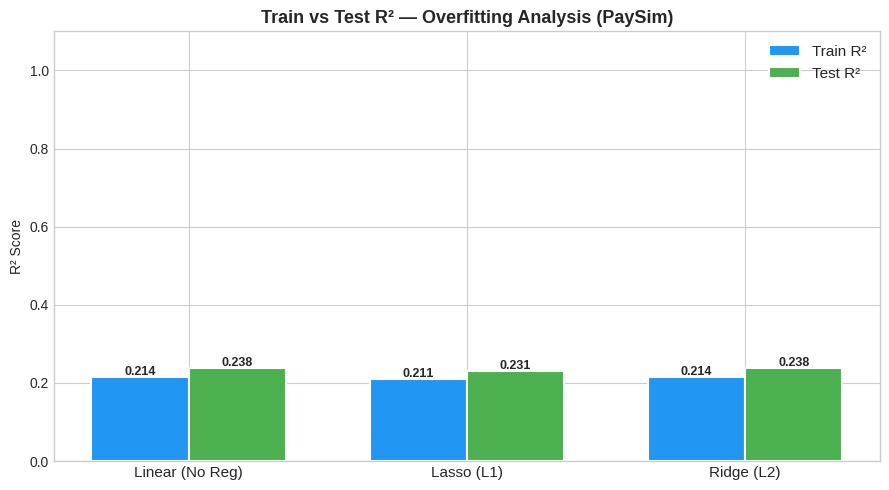


Key Observation:
  OLS   gap : -0.0232
  Lasso gap : -0.0195  (L1 reduces overfit)
  Ridge gap : -0.0232  (L2 reduces overfit)


In [5]:
print("  CORE CONCEPT: WHY REGULARIZATION?")
print("  Demonstrating Overfitting vs Regularized Models on PaySim")

# Baseline: OLS (no regularization)
ols = LinearRegression()
ols.fit(X_reg_train, y_reg_train)
ols_train_r2 = r2_score(y_reg_train, ols.predict(X_reg_train))
ols_test_r2  = r2_score(y_reg_test,  ols.predict(X_reg_test))
print(f"\nLinear Regression (NO regularization):")
print(f"  Train R² = {ols_train_r2:.4f}  |  Test R² = {ols_test_r2:.4f}")
print(f"  Gap (Overfit indicator) = {ols_train_r2 - ols_test_r2:.4f}")
print(f"  Largest 3 coefficients: {sorted(np.abs(ols.coef_), reverse=True)[:3]}")

# L1 Lasso
lasso_demo = Lasso(alpha=0.05, max_iter=10000, random_state=42)
lasso_demo.fit(X_reg_train, y_reg_train)
lasso_train_r2 = r2_score(y_reg_train, lasso_demo.predict(X_reg_train))
lasso_test_r2  = r2_score(y_reg_test,  lasso_demo.predict(X_reg_test))
zero_coefs = np.sum(lasso_demo.coef_ == 0)
print(f"\nLasso Regression (L1, alpha=0.05):")
print(f"  Train R² = {lasso_train_r2:.4f}  |  Test R² = {lasso_test_r2:.4f}")
print(f"  Coefficients driven to ZERO: {zero_coefs} / {len(lasso_demo.coef_)}")
print(f"  → L1 performs automatic feature selection!")

# L2 Ridge
ridge_demo = Ridge(alpha=1.0)
ridge_demo.fit(X_reg_train, y_reg_train)
ridge_train_r2 = r2_score(y_reg_train, ridge_demo.predict(X_reg_train))
ridge_test_r2  = r2_score(y_reg_test,  ridge_demo.predict(X_reg_test))
print(f"\nRidge Regression (L2, alpha=1.0):")
print(f"  Train R² = {ridge_train_r2:.4f}  |  Test R² = {ridge_test_r2:.4f}")
print(f"  → L2 shrinks ALL coefficients but keeps all features.")

# VISUALIZATION 1: Coefficient Comparison
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
models_demo = {
    'Linear Regression\n(No Regularization)': (ols.coef_,        '#9E9E9E'),
    'Lasso — L1\n(alpha=0.05)':               (lasso_demo.coef_, '#F44336'),
    'Ridge — L2\n(alpha=1.0)':                (ridge_demo.coef_, '#2196F3'),
}
for ax, (title, (coefs, color)) in zip(axes, models_demo.items()):
    bars = ax.bar(range(len(coefs)), coefs,
                  color=color, edgecolor='white', linewidth=0.8, alpha=0.85)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xticks(range(len(coefs)))
    ax.set_xticklabels(reg_feature_names, rotation=45, ha='right', fontsize=8)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel('Coefficient Value')
    if 'Lasso' in title:
        zc = np.sum(np.abs(coefs) < 1e-4)
        ax.text(0.5, 0.95, f'{zc} coefs = 0\n(feature selection)',
                transform=ax.transAxes, ha='center', va='top',
                fontsize=9, color='red',
                bbox=dict(boxstyle='round', fc='white', ec='red', alpha=0.8))

plt.suptitle('L1 vs L2 Regularization — Effect on Coefficients (PaySim)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('coefficient_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# VISUALIZATION 2: Train vs Test R² Gap
fig, ax = plt.subplots(figsize=(9, 5))
model_names_demo = ['Linear (No Reg)', 'Lasso (L1)', 'Ridge (L2)']
train_r2s = [ols_train_r2, lasso_train_r2, ridge_train_r2]
test_r2s  = [ols_test_r2,  lasso_test_r2,  ridge_test_r2]
x_pos = np.arange(len(model_names_demo))
width = 0.35
bars1 = ax.bar(x_pos - width/2, train_r2s, width, label='Train R²', color='#2196F3',
               edgecolor='white', linewidth=1.5)
bars2 = ax.bar(x_pos + width/2, test_r2s,  width, label='Test R²',  color='#4CAF50',
               edgecolor='white', linewidth=1.5)
for bar, val in zip(list(bars1)+list(bars2), train_r2s+test_r2s):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(model_names_demo, fontsize=11)
ax.set_ylabel('R² Score'); ax.set_ylim(0, 1.1)
ax.set_title('Train vs Test R² — Overfitting Analysis (PaySim)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('overfitting_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nKey Observation:")
print(f"  OLS   gap : {ols_train_r2   - ols_test_r2:.4f}")
print(f"  Lasso gap : {lasso_train_r2 - lasso_test_r2:.4f}  (L1 reduces overfit)")
print(f"  Ridge gap : {ridge_train_r2 - ridge_test_r2:.4f}  (L2 reduces overfit)")


###6. REGRESSION MODEL TRAINING

In [6]:
print("  BLOCK 6: REGRESSION MODEL TRAINING")

# 6.1 Optimal Alpha via Cross-Validation
print("\nFinding optimal alpha via Cross-Validation (RidgeCV / LassoCV)...")
alphas_to_try = np.logspace(-3, 3, 100)

ridge_cv = RidgeCV(alphas=alphas_to_try, cv=5)
ridge_cv.fit(X_reg_train, y_reg_train)
best_alpha_ridge = ridge_cv.alpha_

lasso_cv = LassoCV(alphas=alphas_to_try, cv=5, max_iter=10000, random_state=42)
lasso_cv.fit(X_reg_train, y_reg_train)
best_alpha_lasso = lasso_cv.alpha_

print(f"  Best alpha — Ridge (L2) : {best_alpha_ridge:.4f}")
print(f"  Best alpha — Lasso (L1) : {best_alpha_lasso:.4f}")

# 6.2 Train All Regression Models
reg_models = {
    'Linear Regression\n(No Regularization)': LinearRegression(),
    'Ridge — L2\n(alpha optimal)':  Ridge(alpha=best_alpha_ridge),
    'Ridge — L2\n(alpha=0.1)':      Ridge(alpha=0.1),
    'Ridge — L2\n(alpha=10.0)':     Ridge(alpha=10.0),
    'Lasso — L1\n(alpha optimal)':  Lasso(alpha=best_alpha_lasso, max_iter=10000, random_state=42),
    'Lasso — L1\n(alpha=0.01)':     Lasso(alpha=0.01,  max_iter=10000, random_state=42),
    'Lasso — L1\n(alpha=0.5)':      Lasso(alpha=0.5,   max_iter=10000, random_state=42),
    'ElasticNet\n(L1+L2)':          ElasticNet(alpha=best_alpha_lasso, l1_ratio=0.5,
                                                max_iter=10000, random_state=42),
}

reg_results = {}
for name, model in reg_models.items():
    model.fit(X_reg_train, y_reg_train)
    y_pred_train = model.predict(X_reg_train)
    y_pred_test  = model.predict(X_reg_test)
    reg_results[name] = {
        'Train R²':  r2_score(y_reg_train, y_pred_train),
        'Test R²':   r2_score(y_reg_test,  y_pred_test),
        'Train RMSE': np.sqrt(mean_squared_error(y_reg_train, y_pred_train)),
        'Test RMSE':  np.sqrt(mean_squared_error(y_reg_test,  y_pred_test)),
        'Test MAE':   mean_absolute_error(y_reg_test, y_pred_test),
        'model': model
    }
    short = name.replace('\n', ' ')
    print(f"  {short:<42} | "
          f"Test R²={reg_results[name]['Test R²']:.4f} | "
          f"RMSE={reg_results[name]['Test RMSE']:.4f}")

print("\nAll regression models trained successfully.")


  BLOCK 6: REGRESSION MODEL TRAINING

Finding optimal alpha via Cross-Validation (RidgeCV / LassoCV)...
  Best alpha — Ridge (L2) : 1000.0000
  Best alpha — Lasso (L1) : 0.0107
  Linear Regression (No Regularization)      | Test R²=0.2377 | RMSE=1.8713
  Ridge — L2 (alpha optimal)                 | Test R²=0.2366 | RMSE=1.8727
  Ridge — L2 (alpha=0.1)                     | Test R²=0.2377 | RMSE=1.8713
  Ridge — L2 (alpha=10.0)                    | Test R²=0.2377 | RMSE=1.8713
  Lasso — L1 (alpha optimal)                 | Test R²=0.2367 | RMSE=1.8725
  Lasso — L1 (alpha=0.01)                    | Test R²=0.2368 | RMSE=1.8724
  Lasso — L1 (alpha=0.5)                     | Test R²=0.0931 | RMSE=2.0411
  ElasticNet (L1+L2)                         | Test R²=0.2370 | RMSE=1.8721

All regression models trained successfully.


###7. ALPHA SENSITIVITY ANALYSIS

  BLOCK 7: ALPHA SENSITIVITY ANALYSIS


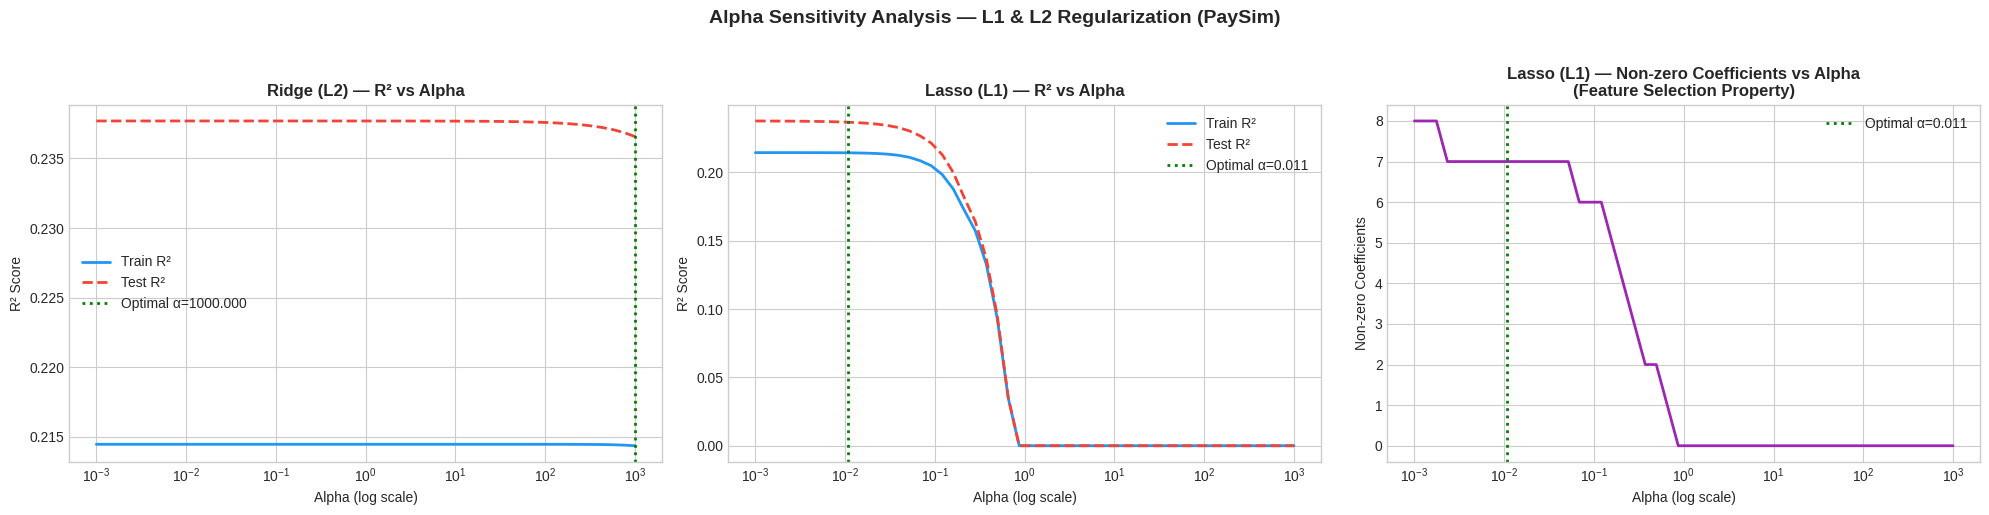

Alpha sensitivity plots saved.


In [7]:
print("  BLOCK 7: ALPHA SENSITIVITY ANALYSIS")

alpha_range = np.logspace(-3, 3, 50)
ridge_test_r2s, ridge_train_r2s = [], []
lasso_test_r2s, lasso_train_r2s = [], []
lasso_nonzero_coefs = []

for a in alpha_range:
    r = Ridge(alpha=a)
    r.fit(X_reg_train, y_reg_train)
    ridge_train_r2s.append(r2_score(y_reg_train, r.predict(X_reg_train)))
    ridge_test_r2s.append( r2_score(y_reg_test,  r.predict(X_reg_test)))

    l = Lasso(alpha=a, max_iter=10000, random_state=42)
    l.fit(X_reg_train, y_reg_train)
    lasso_train_r2s.append(r2_score(y_reg_train, l.predict(X_reg_train)))
    lasso_test_r2s.append( r2_score(y_reg_test,  l.predict(X_reg_test)))
    lasso_nonzero_coefs.append(np.sum(l.coef_ != 0))

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Ridge R² vs alpha
axes[0].semilogx(alpha_range, ridge_train_r2s, color='#2196F3', lw=2, label='Train R²')
axes[0].semilogx(alpha_range, ridge_test_r2s,  color='#F44336', lw=2, linestyle='--', label='Test R²')
axes[0].axvline(best_alpha_ridge, color='green', linestyle=':', lw=2,
                label=f'Optimal α={best_alpha_ridge:.3f}')
axes[0].set_title('Ridge (L2) — R² vs Alpha', fontweight='bold')
axes[0].set_xlabel('Alpha (log scale)'); axes[0].set_ylabel('R² Score')
axes[0].legend()

# Lasso R² vs alpha
axes[1].semilogx(alpha_range, lasso_train_r2s, color='#2196F3', lw=2, label='Train R²')
axes[1].semilogx(alpha_range, lasso_test_r2s,  color='#F44336', lw=2, linestyle='--', label='Test R²')
axes[1].axvline(best_alpha_lasso, color='green', linestyle=':', lw=2,
                label=f'Optimal α={best_alpha_lasso:.3f}')
axes[1].set_title('Lasso (L1) — R² vs Alpha', fontweight='bold')
axes[1].set_xlabel('Alpha (log scale)'); axes[1].set_ylabel('R² Score')
axes[1].legend()

# Lasso non-zero coefficients vs alpha (Feature Selection Property)
axes[2].semilogx(alpha_range, lasso_nonzero_coefs, color='#9C27B0', lw=2)
axes[2].axvline(best_alpha_lasso, color='green', linestyle=':', lw=2,
                label=f'Optimal α={best_alpha_lasso:.3f}')
axes[2].set_title('Lasso (L1) — Non-zero Coefficients vs Alpha\n(Feature Selection Property)',
                  fontweight='bold')
axes[2].set_xlabel('Alpha (log scale)'); axes[2].set_ylabel('Non-zero Coefficients')
axes[2].legend()

plt.suptitle('Alpha Sensitivity Analysis — L1 & L2 Regularization (PaySim)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('alpha_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()
print("Alpha sensitivity plots saved.")


###8. CLASSIFICATION MODEL TRAINING

In [8]:
print("  BLOCK 8: CLASSIFICATION MODEL TRAINING (5-Class: Transaction Type)")
print(f"  Classes: {list(le_type.classes_)}")

# ── Stratified 5k subsample for slow models (KNN, LinearSVC) ──────────────
# KNN prediction is O(n²) at test time; LinearSVC scales poorly with OvR
# 1000 samples per class × 5 classes = 5000 samples — sufficient signal
subsample_idx = (
    pd.Series(y_clf_train.values, index=X_clf_train.index)
    .groupby(y_clf_train.values)
    .apply(lambda x: x.sample(min(len(x), 1000), random_state=42))
    .index.get_level_values(1)
)
X_clf_train_small = X_clf_train.loc[subsample_idx]
y_clf_train_small = y_clf_train.loc[subsample_idx]
print(f"  Subsampled training set for KNN / LinearSVC: {X_clf_train_small.shape[0]} samples")

# Models that must be trained on the 5k subsample
SMALL_TRAIN_MODELS = {'KNN\n(k=5)',  'LinearSVC\n(SVM-linear)'}

clf_models = {
    # ── Logistic Regression — 5 regularization variants ───────────────────
    'Logistic Reg\n(No Reg)':
        LogisticRegression(penalty=None, solver='lbfgs', max_iter=2000,
                           multi_class='multinomial', random_state=42),
    'Logistic Reg\nL2 (C=1.0)':
        LogisticRegression(penalty='l2', C=1.0, solver='lbfgs', max_iter=2000,
                           multi_class='multinomial', random_state=42),
    'Logistic Reg\nL2 (C=0.01)':
        LogisticRegression(penalty='l2', C=0.01, solver='lbfgs', max_iter=2000,
                           multi_class='multinomial', random_state=42),
    'Logistic Reg\nL1 (C=1.0)':
        LogisticRegression(penalty='l1', C=1.0, solver='saga', max_iter=2000,
                           multi_class='multinomial', random_state=42),
    'Logistic Reg\nL1 (C=0.1)':
        LogisticRegression(penalty='l1', C=0.1, solver='saga', max_iter=2000,
                           multi_class='multinomial', random_state=42),

    # ── SGD Classifier (existing) ──────────────────────────────────────────
    'SGD Classifier\n(L2 — fast)':
        SGDClassifier(loss='modified_huber', penalty='l2', alpha=0.001,
                      max_iter=1000, random_state=42, n_jobs=-1),

    # ── Naïve Bayes — Lab 5 (Spam Detection) ──────────────────────────────
    'Gaussian\nNaïve Bayes':
        GaussianNB(),

    # ── KNN — Lab 8, 9, 10 — trained on 5k subsample ──────────────────────
    'KNN\n(k=5)':
        KNeighborsClassifier(n_neighbors=5, n_jobs=-1),

    # ── LinearSVC — Lab 5, 9 (SVM) — calibrated for predict_proba ─────────
    # LinearSVC is mathematically equivalent to SVC(kernel='linear')
    # but uses LibLinear (O(n) scaling) instead of LibSVM (O(n²))
    # CalibratedClassifierCV wrapper adds predict_proba support
    'LinearSVC\n(SVM-linear)':
        CalibratedClassifierCV(LinearSVC(max_iter=2000, random_state=42), cv=3),

    # ── Decision Trees (existing) ──────────────────────────────────────────
    'Decision Tree\n(No Reg)':
        DecisionTreeClassifier(max_depth=None, random_state=42),
    'Decision Tree\n(Regularized)':
        DecisionTreeClassifier(max_depth=8, min_samples_split=20,
                               min_samples_leaf=10, random_state=42),

    # ── Bagging Classifier — Lab 11 (Diabetes Ensemble) ───────────────────
    'Bagging\n(20 DTs)':
        BaggingClassifier(estimator=DecisionTreeClassifier(),
                          n_estimators=20, random_state=42, n_jobs=-1),

    # ── Random Forest (existing) ───────────────────────────────────────────
    'Random Forest\n(Ensemble)':
        RandomForestClassifier(n_estimators=100, max_depth=10,
                               random_state=42, n_jobs=-1),

    # ── XGBoost — Lab 6, 8 (Credit Risk, Student Performance) ─────────────
    'XGBoost\n(Grad. Boost)':
        XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1,
                      eval_metric='mlogloss', random_state=42, verbosity=0),
}

cv_strat    = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_strat_3  = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)  # for subsampled models
clf_results = {}

for name, model in clf_models.items():
    short = name.replace('\n', ' ')
    print(f"  Training: {short:<38}", end=' | ')

    # ── Choose correct training set ────────────────────────────────────────
    if name in SMALL_TRAIN_MODELS:
        model.fit(X_clf_train_small, y_clf_train_small)
        # Use 3-fold CV on the same 5k subsample to stay fast
        cv_scores = cross_val_score(model, X_clf_train_small, y_clf_train_small,
                                    cv=cv_strat_3, scoring='f1_macro')
    else:
        model.fit(X_clf_train, y_clf_train)
        cv_scores = cross_val_score(model, X_clf_scaled, y_clf,
                                    cv=cv_strat, scoring='f1_macro')

    y_pred = model.predict(X_clf_test)

    # predict_proba: all models support it (LinearSVC wrapped with CalibratedClassifierCV)
    try:
        y_prob = model.predict_proba(X_clf_test)
    except AttributeError:
        y_prob = np.zeros((len(y_clf_test), 5))

    clf_results[name] = {
        'Accuracy':   accuracy_score(y_clf_test, y_pred),
        'Precision':  precision_score(y_clf_test, y_pred, average='macro', zero_division=0),
        'Recall':     recall_score(y_clf_test, y_pred, average='macro'),
        'F1 Score':   f1_score(y_clf_test, y_pred, average='macro'),
        'CV F1 Mean': cv_scores.mean(),
        'CV F1 Std':  cv_scores.std(),
        'y_pred':     y_pred,
        'y_prob':     y_prob,
        'subsample':  name in SMALL_TRAIN_MODELS
    }

    tag = '(5k subsample)' if name in SMALL_TRAIN_MODELS else ''
    print(f"Acc={clf_results[name]['Accuracy']:.3f}  F1={clf_results[name]['F1 Score']:.3f}  {tag}")

print(f"\nAll {len(clf_models)} classification models trained successfully.")
print("Note: KNN and LinearSVC trained on stratified 5k subsample for speed.")
print("5×5 Confusion Matrix ready in Block 9.")

  BLOCK 8: CLASSIFICATION MODEL TRAINING (5-Class: Transaction Type)
  Classes: ['CASH_IN', 'CASH_OUT', 'DEBIT', 'PAYMENT', 'TRANSFER']
  Subsampled training set for KNN / LinearSVC: 5000 samples
  Training: Logistic Reg (No Reg)                  | Acc=0.875  F1=0.875  
  Training: Logistic Reg L2 (C=1.0)                | Acc=0.837  F1=0.838  
  Training: Logistic Reg L2 (C=0.01)               | Acc=0.769  F1=0.764  
  Training: Logistic Reg L1 (C=1.0)                | Acc=0.843  F1=0.843  
  Training: Logistic Reg L1 (C=0.1)                | Acc=0.837  F1=0.837  
  Training: SGD Classifier (L2 — fast)             | Acc=0.779  F1=0.765  
  Training: Gaussian Naïve Bayes                   | Acc=0.635  F1=0.622  
  Training: KNN (k=5)                              | Acc=0.797  F1=0.795  (5k subsample)
  Training: LinearSVC (SVM-linear)                 | Acc=0.807  F1=0.802  (5k subsample)
  Training: Decision Tree (No Reg)                 | Acc=0.840  F1=0.843  
  Training: Decision Tree 

###9. EVALUATION & VISUALIZATIONS

  BLOCK 9: EVALUATION & VISUALIZATIONS

  Logistic Reg (No Reg)
              precision    recall  f1-score   support

     CASH_IN       1.00      1.00      1.00      2000
    CASH_OUT       0.69      0.76      0.73      2000
       DEBIT       0.90      0.98      0.94      1633
     PAYMENT       0.99      1.00      0.99      2000
    TRANSFER       0.80      0.65      0.72      2000

    accuracy                           0.87      9633
   macro avg       0.88      0.88      0.88      9633
weighted avg       0.88      0.87      0.87      9633


  Logistic Reg L2 (C=1.0)
              precision    recall  f1-score   support

     CASH_IN       1.00      0.97      0.99      2000
    CASH_OUT       0.62      0.72      0.67      2000
       DEBIT       0.84      0.84      0.84      1633
     PAYMENT       0.96      1.00      0.98      2000
    TRANSFER       0.80      0.65      0.72      2000

    accuracy                           0.84      9633
   macro avg       0.84      0.84      0

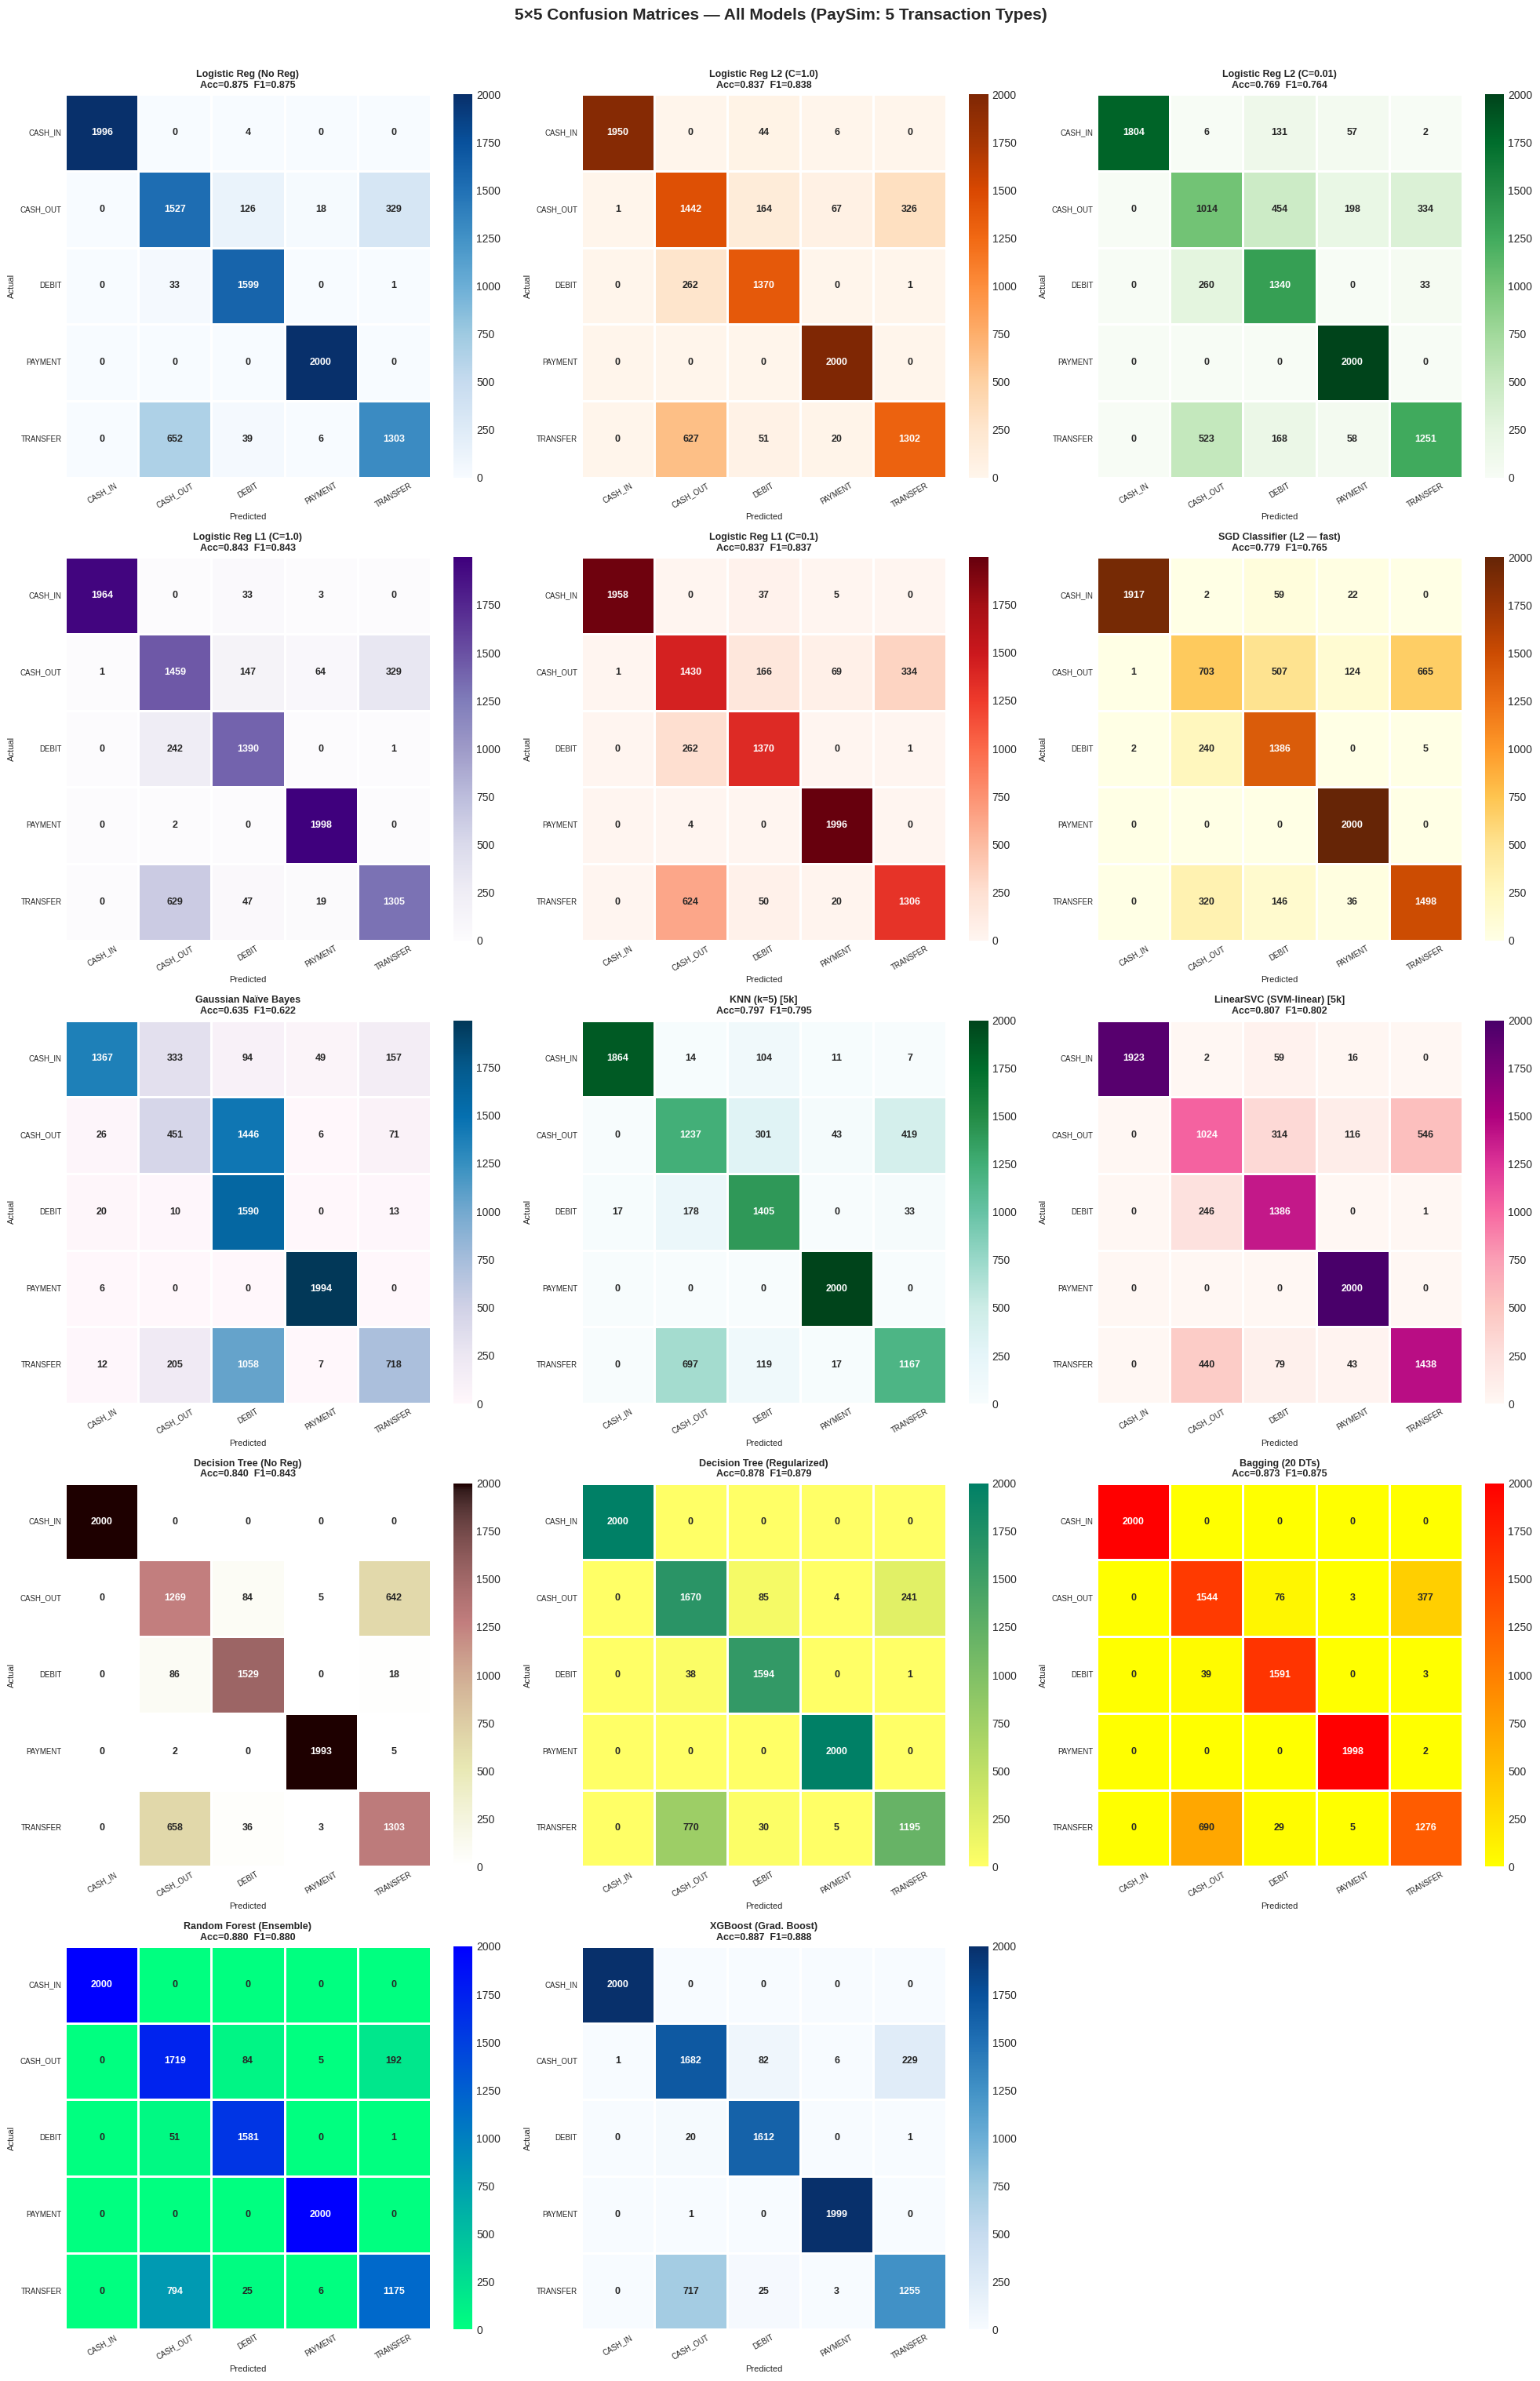

5×5 Confusion Matrices done!


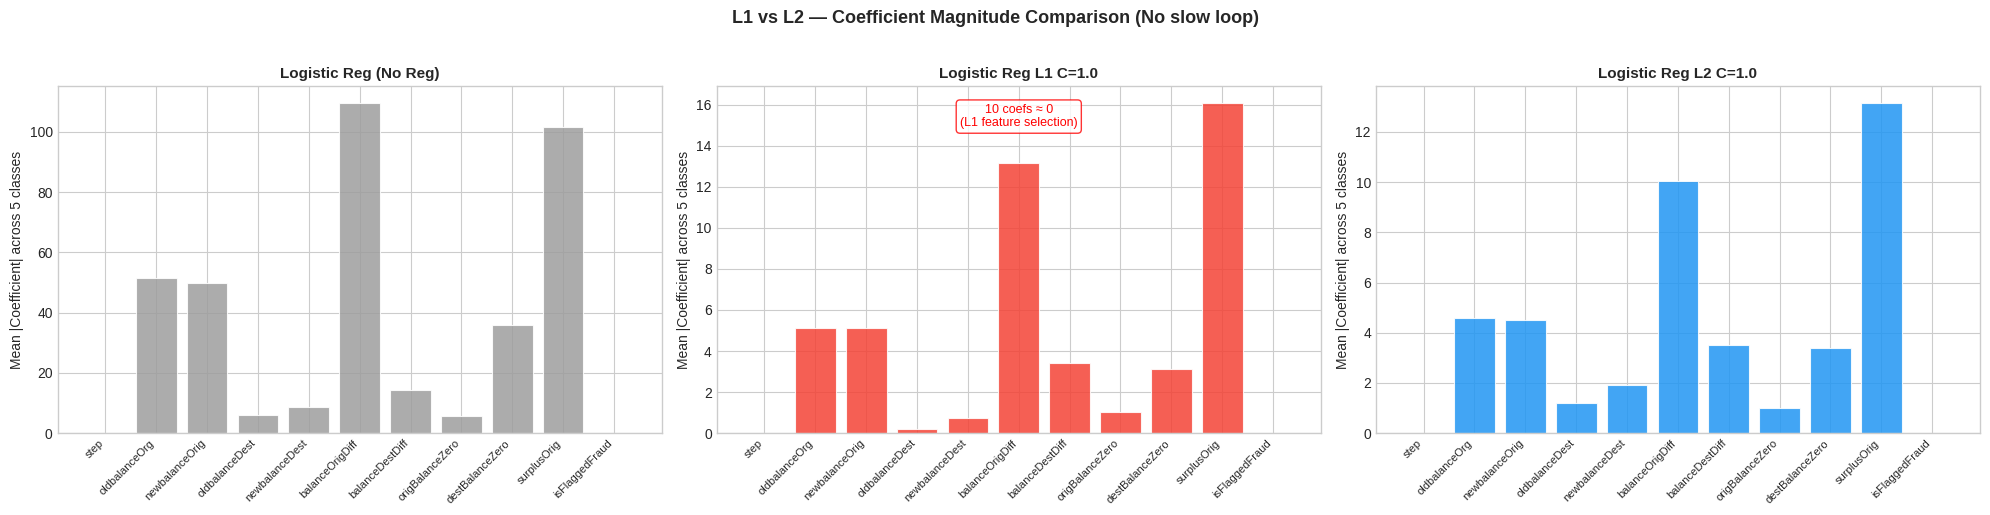

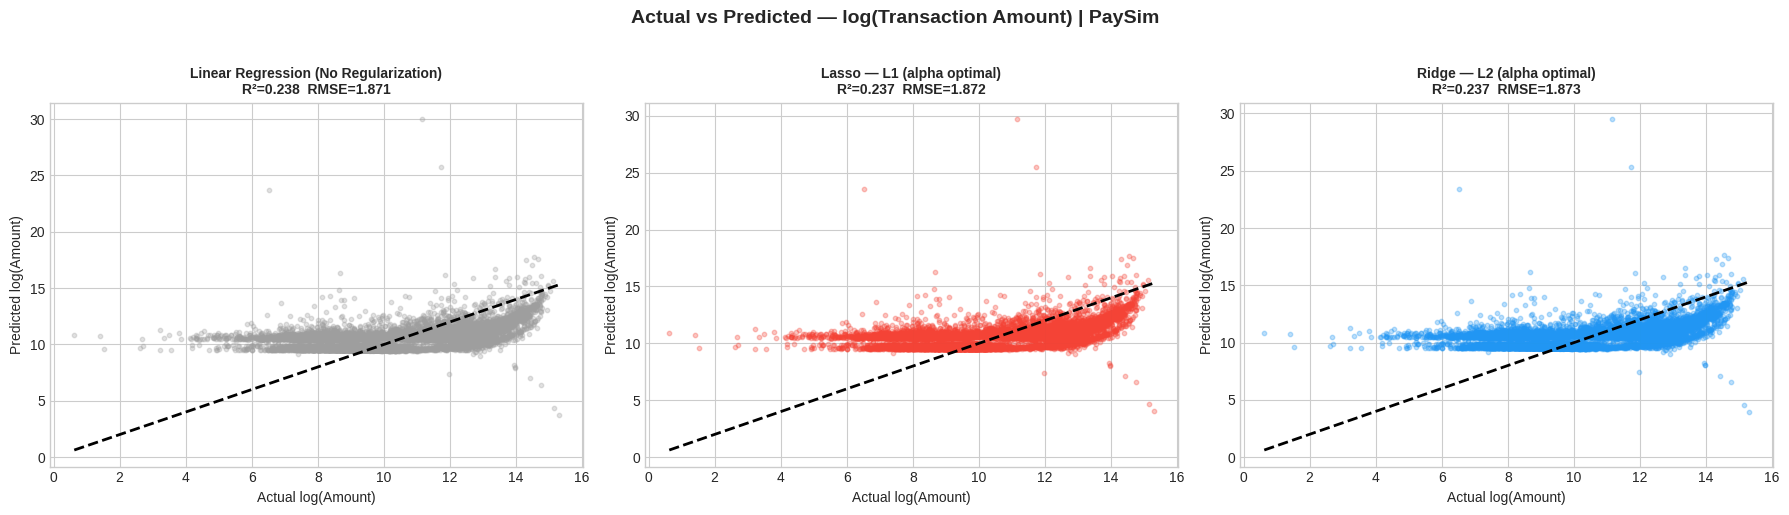

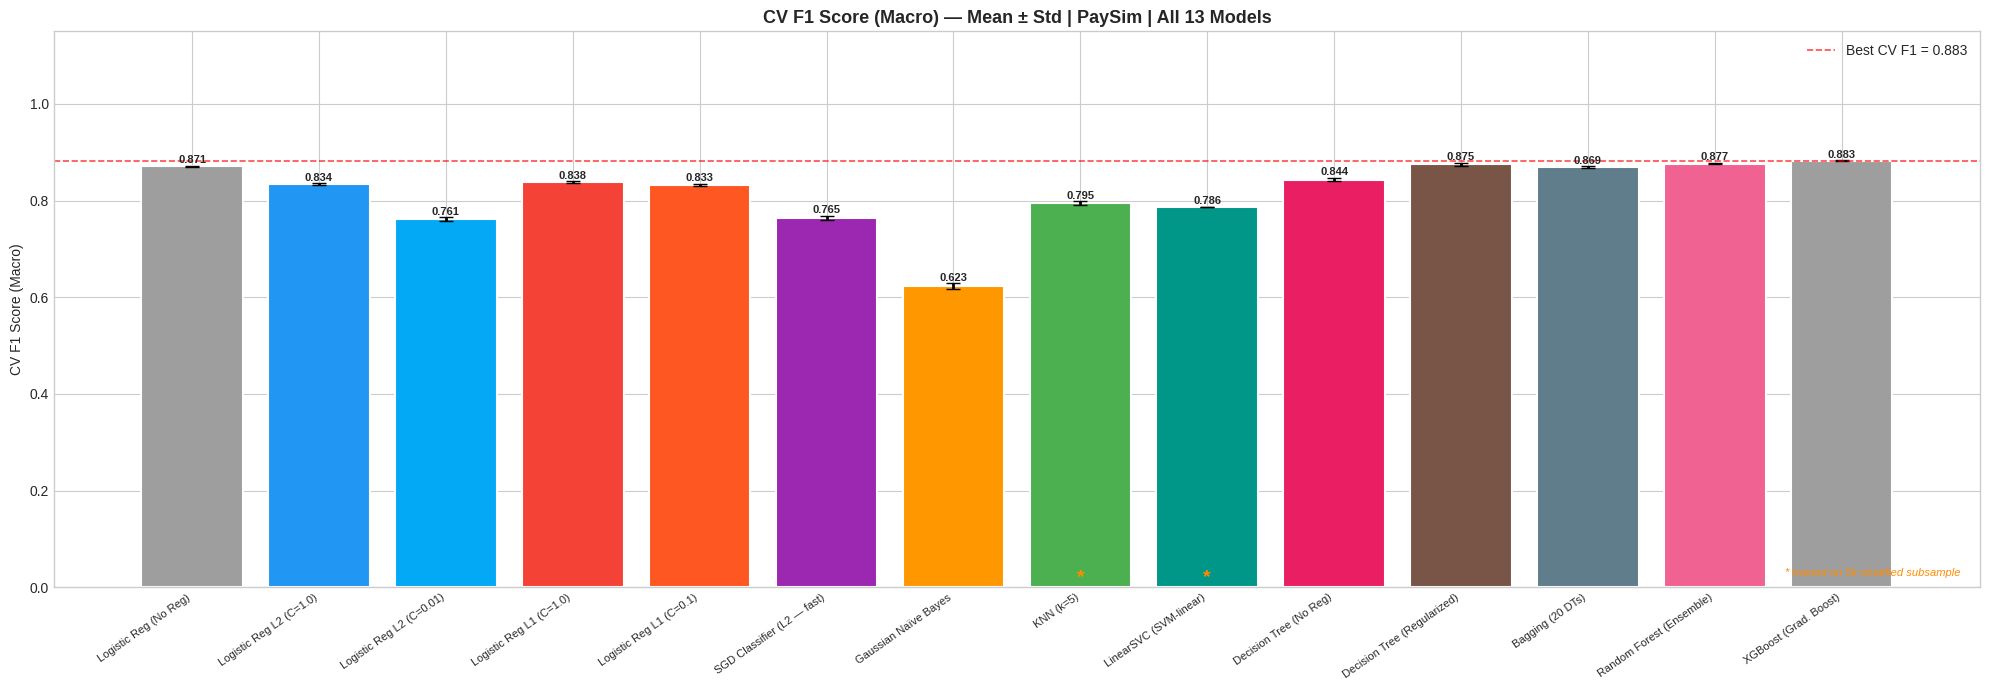

In [9]:
print("  BLOCK 9: EVALUATION & VISUALIZATIONS")

class_names = list(le_type.classes_)  # ['CASH_IN','CASH_OUT','DEBIT','PAYMENT','TRANSFER']

# ── 9.1 Classification Reports ───────────────────────────────────────────
for name, res in clf_results.items():
    short = name.replace('\n', ' ')
    print(f"\n{'='*60}")
    print(f"  {short}")
    print(f"{'='*60}")
    print(classification_report(y_clf_test, res['y_pred'],
                                target_names=class_names))

# ── 9.2 5×5 CONFUSION MATRICES ───────────────────────────────────────────
n_models = len(clf_models)
n_cols = 3
n_rows = (n_models + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 6 * n_rows))
axes = axes.ravel()
cmaps = ['Blues','Oranges','Greens','Purples','Reds','YlOrBr','PuBu','BuGn','RdPu',
         'pink_r','summer_r','autumn_r','winter_r']  # extended to cover 13 models

for idx, (name, res) in enumerate(clf_results.items()):
    cm = confusion_matrix(y_clf_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmaps[idx % len(cmaps)],
                ax=axes[idx],
                xticklabels=class_names, yticklabels=class_names,
                linewidths=1, linecolor='white',
                annot_kws={'size': 9, 'weight': 'bold'})
    short = name.replace('\n', ' ')
    # Add subsample note to title if applicable
    sub_note = ' [5k]' if clf_results[name].get('subsample', False) else ''
    axes[idx].set_title(
        f'{short}{sub_note}\nAcc={res["Accuracy"]:.3f}  F1={res["F1 Score"]:.3f}',
        fontsize=9, fontweight='bold')
    axes[idx].set_xlabel('Predicted', fontsize=8)
    axes[idx].set_ylabel('Actual',    fontsize=8)
    axes[idx].tick_params(axis='x', rotation=30, labelsize=7)
    axes[idx].tick_params(axis='y', rotation=0,  labelsize=7)

for j in range(len(clf_results), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('5×5 Confusion Matrices — All Models (PaySim: 5 Transaction Types)',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('confusion_matrices_5x5.png', dpi=150, bbox_inches='tight')
plt.show()
print("5×5 Confusion Matrices done!")

# ── 9.3 L1 vs L2 Coefficient Comparison (NO slow loop) ──────────────────
# Compare coefficients of already-trained L1 and L2 models directly
l1_model = clf_models['Logistic Reg\nL1 (C=1.0)']
l2_model = clf_models['Logistic Reg\nL2 (C=1.0)']
no_reg   = clf_models['Logistic Reg\n(No Reg)']

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
coef_titles = [
    ('Logistic Reg (No Reg)',  no_reg.coef_,   '#9E9E9E'),
    ('Logistic Reg L1 C=1.0', l1_model.coef_, '#F44336'),
    ('Logistic Reg L2 C=1.0', l2_model.coef_, '#2196F3'),
]
for ax, (title, coefs, color) in zip(axes, coef_titles):
    # Show mean absolute coefficient per feature across all 5 classes
    mean_abs = np.mean(np.abs(coefs), axis=0)
    ax.bar(range(len(mean_abs)), mean_abs, color=color,
           edgecolor='white', linewidth=0.8, alpha=0.85)
    ax.set_xticks(range(len(clf_feature_cols)))
    ax.set_xticklabels(clf_feature_cols, rotation=45, ha='right', fontsize=8)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel('Mean |Coefficient| across 5 classes')
    if 'L1' in title:
        zero_count = np.sum(np.abs(coefs) < 1e-4)
        ax.text(0.5, 0.95, f'{zero_count} coefs ≈ 0\n(L1 feature selection)',
                transform=ax.transAxes, ha='center', va='top',
                fontsize=9, color='red',
                bbox=dict(boxstyle='round', fc='white', ec='red', alpha=0.8))

plt.suptitle('L1 vs L2 — Coefficient Magnitude Comparison (No slow loop)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('classification_regularization.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 9.4 Regression: Actual vs Predicted ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
reg_to_plot = ['Linear Regression\n(No Regularization)',
               'Lasso — L1\n(alpha optimal)',
               'Ridge — L2\n(alpha optimal)']
colors_reg = ['#9E9E9E', '#F44336', '#2196F3']

for ax, name, color in zip(axes, reg_to_plot, colors_reg):
    model_r     = reg_results[name]['model']
    y_pred_plot = model_r.predict(X_reg_test)
    ax.scatter(y_reg_test, y_pred_plot, alpha=0.3, color=color, s=10)
    mn, mx = y_reg_test.min(), y_reg_test.max()
    ax.plot([mn, mx], [mn, mx], 'k--', lw=2, label='Perfect Fit')
    short = name.replace('\n', ' ')
    ax.set_title(f'{short}\nR²={reg_results[name]["Test R²"]:.3f}  '
                 f'RMSE={reg_results[name]["Test RMSE"]:.3f}',
                 fontsize=10, fontweight='bold')
    ax.set_xlabel('Actual log(Amount)')
    ax.set_ylabel('Predicted log(Amount)')

plt.suptitle('Actual vs Predicted — log(Transaction Amount) | PaySim',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 9.5 Cross-Validation Bar Chart ───────────────────────────────────────
# Extended figure width and color palette to handle 13 models cleanly
fig, ax = plt.subplots(figsize=(20, 7))  # wider than original (14,6) for 13 models
short_names  = [n.replace('\n', ' ') for n in clf_results.keys()]
cv_means_clf = [clf_results[n]['CV F1 Mean'] for n in clf_results]
cv_stds_clf  = [clf_results[n]['CV F1 Std']  for n in clf_results]
colors_bar   = ['#9E9E9E','#2196F3','#03A9F4','#F44336','#FF5722',
                '#9C27B0','#FF9800','#4CAF50','#009688',
                '#E91E63','#795548','#607D8B','#F06292']  # extended to 13 colors

bars = ax.bar(short_names, cv_means_clf, yerr=cv_stds_clf, capsize=5,
              color=colors_bar[:len(clf_results)], edgecolor='white', linewidth=1.5,
              error_kw={'elinewidth': 2, 'ecolor': 'black'})
for bar, val, std in zip(bars, cv_means_clf, cv_stds_clf):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + std + 0.005,
            f'{val:.3f}', ha='center', fontsize=8, fontweight='bold')

ax.set_ylim(0, 1.15)
ax.set_ylabel('CV F1 Score (Macro)')
ax.set_title('CV F1 Score (Macro) — Mean ± Std | PaySim | All 13 Models',
             fontsize=13, fontweight='bold')
ax.axhline(y=max(cv_means_clf), color='red', linestyle='--',
           linewidth=1.2, alpha=0.7,
           label=f'Best CV F1 = {max(cv_means_clf):.3f}')

# Annotate subsampled models with a marker on the x-axis
for i, name in enumerate(clf_results.keys()):
    if clf_results[name].get('subsample', False):
        ax.get_xticklabels()  # force draw first
        ax.annotate('*', xy=(i, 0.01), ha='center', fontsize=14,
                    color='darkorange', fontweight='bold')

ax.legend(fontsize=10)
ax.text(0.99, 0.02, '* trained on 5k stratified subsample',
        transform=ax.transAxes, ha='right', fontsize=8,
        color='darkorange', style='italic')
plt.xticks(rotation=35, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig('cv_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
best_clf = max(clf_results, key=lambda n: clf_results[n]['F1 Score'])
print(f"Best Classification Model: {best_clf.replace(chr(10), ' ')}")

Best Classification Model: XGBoost (Grad. Boost)



── 9.6 ROC AUC Curve for Best Classification Model ──


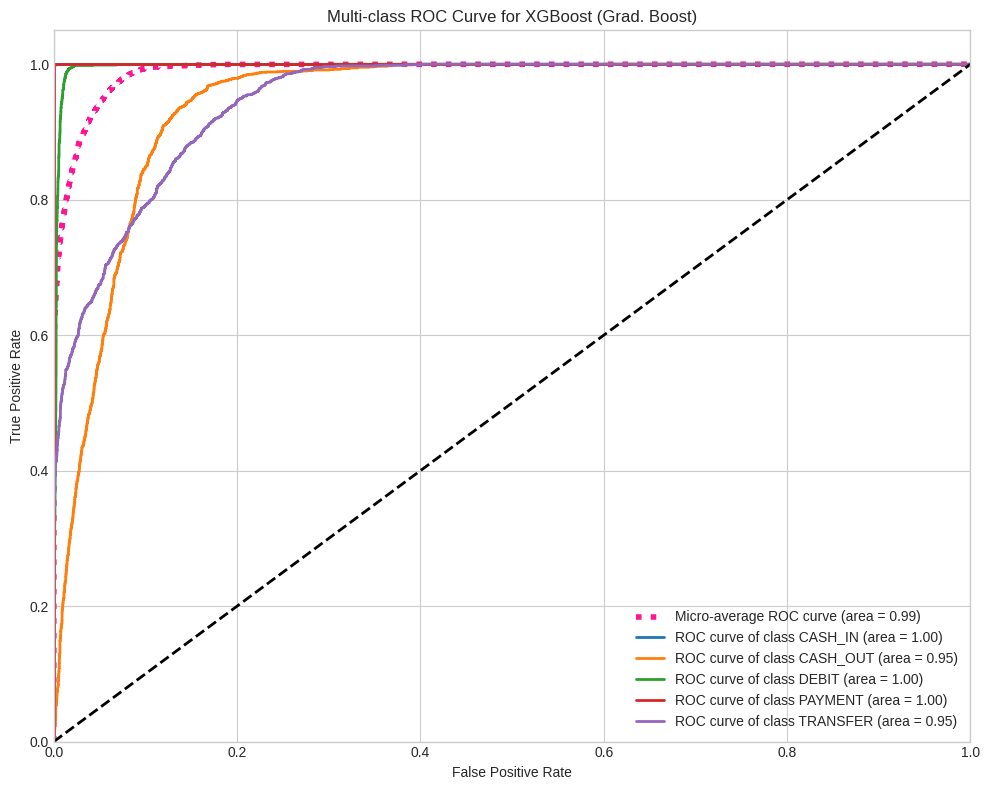

In [16]:
print("\n── 9.6 ROC AUC Curve for Best Classification Model ──")
best_clf_model_name = best_clf
best_clf_y_prob = clf_results[best_clf_model_name]['y_prob']

# For multi-class, we need to calculate ROC AUC for each class
# and then average (macro or weighted).
# First, binarize the output
from sklearn.preprocessing import label_binarize
y_test_binarized = label_binarize(y_clf_test, classes=range(len(class_names)))

# Compute ROC curve and ROC area for each class
n_classes = len(class_names)
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], best_clf_y_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute micro-average ROC curve and ROC area
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_binarized.ravel(), best_clf_y_prob.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Plot ROC curves for each class and micro-average
plt.figure(figsize=(10, 8))
plt.plot(fpr["micro"], tpr["micro"], label=f'Micro-average ROC curve (area = {roc_auc["micro"]:.2f})', color='deeppink', linestyle=':', linewidth=4)

for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], lw=2, label=f'ROC curve of class {class_names[i]} (area = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'Multi-class ROC Curve for {best_clf_model_name.replace(chr(10), " ")}')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.savefig('roc_auc_curve_best_clf.png', dpi=150, bbox_inches='tight')
plt.show()

###10. MODEL COMPARISON TABLES

  BLOCK 10: FINAL MODEL COMPARISON TABLES

REGRESSION MODEL COMPARISON (Target: log transaction amount)
                                       Train R²  Test R²  Train RMSE  Test RMSE  Test MAE  Overfit Gap (R²)
Linear Regression (No Regularization)    0.2145   0.2377      1.9117     1.8713    1.5008           -0.0232
Ridge — L2 (alpha optimal)               0.2144   0.2366      1.9118     1.8727    1.5048           -0.0222
Ridge — L2 (alpha=0.1)                   0.2145   0.2377      1.9117     1.8713    1.5008           -0.0232
Ridge — L2 (alpha=10.0)                  0.2145   0.2377      1.9117     1.8713    1.5008           -0.0232
Lasso — L1 (alpha optimal)               0.2143   0.2367      1.9118     1.8725    1.5047           -0.0224
Lasso — L1 (alpha=0.01)                  0.2143   0.2368      1.9118     1.8724    1.5044           -0.0225
Lasso — L1 (alpha=0.5)                   0.0910   0.0931      2.0564     2.0411    1.7494           -0.0021
ElasticNet (L1+L2)              

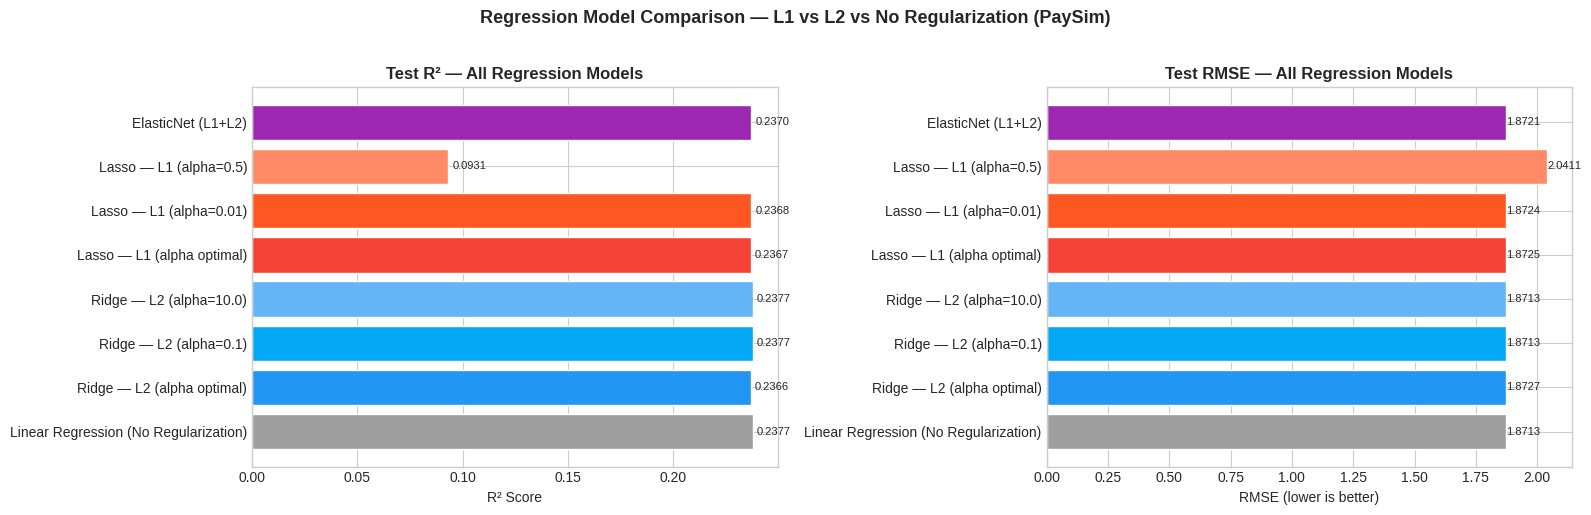


── CLASSIFICATION MODEL COMPARISON (5-class: transaction type) ──
                             Accuracy  Precision  Recall  F1 Score  CV F1 Mean
Logistic Reg (No Reg)          0.8746     0.8762  0.8784    0.8751      0.8706
Logistic Reg L2 (C=1.0)        0.8371     0.8428  0.8372    0.8376      0.8336
Logistic Reg L2 (C=0.01)       0.7691     0.7679  0.7710    0.7639      0.7614
Logistic Reg L1 (C=1.0)        0.8425     0.8483  0.8428    0.8432      0.8380
Logistic Reg L1 (C=0.1)        0.8367     0.8422  0.8368    0.8372      0.8327
SGD Classifier (L2 — fast)     0.7790     0.7645  0.7815    0.7654      0.7649
Gaussian Naïve Bayes           0.6353     0.7010  0.6477    0.6225      0.6232
KNN (k=5)                      0.7965     0.7969  0.7989    0.7951      0.7948
LinearSVC (SVM-linear)         0.8067     0.7992  0.8082    0.8021      0.7865
Decision Tree (No Reg)         0.8402     0.8430  0.8438    0.8434      0.8435
Decision Tree (Regularized)    0.8781     0.8868  0.8817    0.87

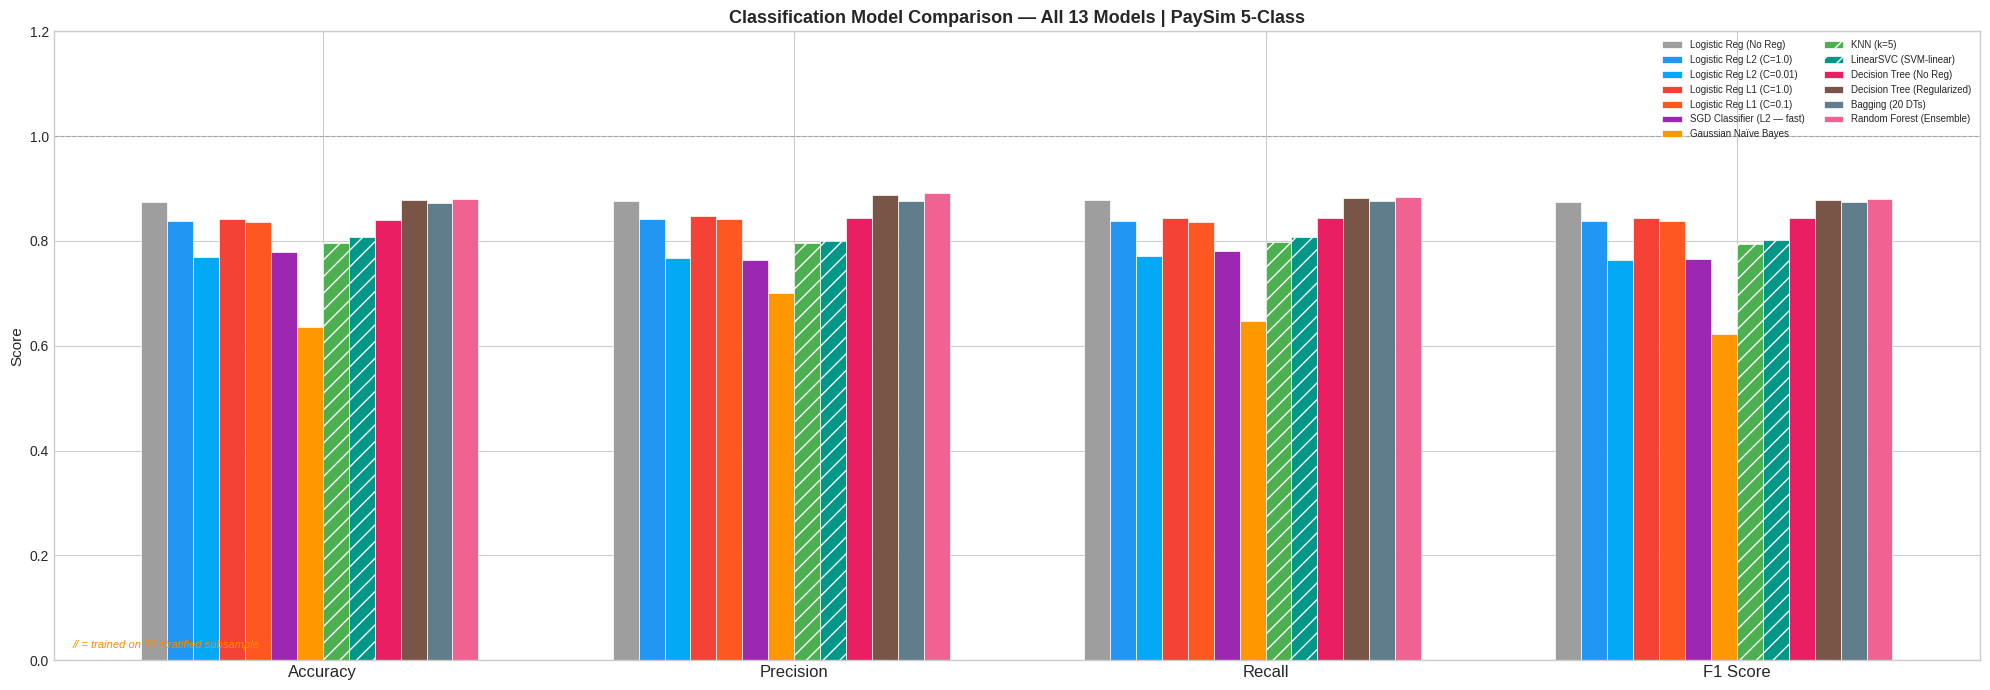

In [13]:
print("  BLOCK 10: FINAL MODEL COMPARISON TABLES")

# 10.1 Regression Comparison
print("\nREGRESSION MODEL COMPARISON (Target: log transaction amount)")
reg_metric_keys = ['Train R²', 'Test R²', 'Train RMSE', 'Test RMSE', 'Test MAE']
reg_compare = pd.DataFrame(
    {name: {k: round(reg_results[name][k], 4) for k in reg_metric_keys}
     for name in reg_results}
).T
reg_compare['Overfit Gap (R²)'] = (reg_compare['Train R²'] - reg_compare['Test R²']).round(4)
reg_compare.index = [i.replace('\n', ' ') for i in reg_compare.index]
print(reg_compare.to_string())

# Regression bar chart
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
model_labels_short = list(reg_compare.index)
test_r2_vals   = list(reg_compare['Test R²'])
test_rmse_vals = list(reg_compare['Test RMSE'])
clrs = ['#9E9E9E','#2196F3','#03A9F4','#64B5F6','#F44336','#FF5722','#FF8A65','#9C27B0']

axes[0].barh(model_labels_short, test_r2_vals, color=clrs, edgecolor='white', linewidth=1)
for i, v in enumerate(test_r2_vals):
    axes[0].text(v + 0.002, i, f'{v:.4f}', va='center', fontsize=8)
axes[0].set_title('Test R² — All Regression Models', fontweight='bold')
axes[0].set_xlabel('R² Score')

axes[1].barh(model_labels_short, test_rmse_vals, color=clrs, edgecolor='white', linewidth=1)
for i, v in enumerate(test_rmse_vals):
    axes[1].text(v + 0.002, i, f'{v:.4f}', va='center', fontsize=8)
axes[1].set_title('Test RMSE — All Regression Models', fontweight='bold')
axes[1].set_xlabel('RMSE (lower is better)')

plt.suptitle('Regression Model Comparison — L1 vs L2 vs No Regularization (PaySim)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('regression_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# 10.2 Classification Comparison
print("\n── CLASSIFICATION MODEL COMPARISON (5-class: transaction type) ──")
clf_metric_keys = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'CV F1 Mean']
clf_compare = pd.DataFrame(
    {name: {k: round(clf_results[name][k], 4) for k in clf_metric_keys}
     for name in clf_results}
).T
clf_compare.index = [i.replace('\n', ' ') for i in clf_compare.index]
print(clf_compare.to_string())

# ── Classification grouped bar chart — extended for 13 models ─────────────
# Full 13-color palette matching Block 9.5 colors
clrs_13 = ['#9E9E9E','#2196F3','#03A9F4','#F44336','#FF5722',
           '#9C27B0','#FF9800','#4CAF50','#009688',
           '#E91E63','#795548','#607D8B','#F06292']

metrics_to_show = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
x      = np.arange(len(metrics_to_show))
n_clf  = len(clf_results)
width  = 0.055  # narrower bars to fit 13 models side-by-side (was 0.08 for 9)
offsets = np.linspace(-(n_clf - 1) * width / 2,
                       (n_clf - 1) * width / 2, n_clf)

fig, ax = plt.subplots(figsize=(20, 7))  # wider + taller than original (15,6)

for (name, res), offset, color in zip(clf_results.items(), offsets, clrs_13):
    vals  = [res[m] for m in metrics_to_show]
    short = name.replace('\n', ' ')
    # Mark subsampled models with hatch pattern for visual distinction
    hatch = '//' if clf_results[name].get('subsample', False) else ''
    ax.bar(x + offset, vals, width, label=short, color=color,
           edgecolor='white', linewidth=0.5, hatch=hatch)

ax.set_xticks(x)
ax.set_xticklabels(metrics_to_show, fontsize=12)
ax.set_ylim(0, 1.2)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Classification Model Comparison — All 13 Models | PaySim 5-Class',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=7, loc='upper right', ncol=2)  # 2-column legend for 13 entries
ax.axhline(y=1.0, color='grey', linestyle='--', lw=0.8, alpha=0.5)
ax.text(0.01, 0.02, '// = trained on 5k stratified subsample',
        transform=ax.transAxes, fontsize=8, color='darkorange', style='italic')
plt.tight_layout()
plt.savefig('classification_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

###11. CONCLUSION & SUMMARY

In [15]:
print("BLOCK 11: CONCLUSION & SUMMARY")

# Regression winner
best_reg = max(
    [n for n in reg_results if 'No Regularization' not in n],
    key=lambda n: reg_results[n]['Test R²']
)
best_reg_r2   = reg_results[best_reg]['Test R²']
best_reg_rmse = reg_results[best_reg]['Test RMSE']
ols_r2_gap = (reg_results['Linear Regression\n(No Regularization)']['Train R²']
            - reg_results['Linear Regression\n(No Regularization)']['Test R²'])

# Classification winner
best_clf     = max(clf_results, key=lambda n: clf_results[n]['F1 Score'])
best_clf_f1  = clf_results[best_clf]['F1 Score']

# Best among linear models only (fair regularization comparison)
linear_models = [n for n in clf_results if 'Logistic' in n or 'SGD' in n]
best_linear     = max(linear_models, key=lambda n: clf_results[n]['F1 Score'])
best_linear_f1  = clf_results[best_linear]['F1 Score']

lasso_zero   = np.sum(reg_results['Lasso — L1\n(alpha optimal)']['model'].coef_ == 0)
total_feats  = X_reg_train.shape[1]
n_clf_models = len(clf_results)
n_reg_models = len(reg_results)

# Count subsampled models
n_subsampled = sum(1 for n in clf_results if clf_results[n].get('subsample', False))

print(f"""
╔══════════════════════════════════════════════════════════╗
║         FINAL RESULTS SUMMARY — PaySim Dataset           ║
╠══════════════════════════════════════════════════════════╣
║  REGRESSION TASK (Predict Transaction Amount)            ║
║  ─────────────────────────────────────────────           ║
║  Models Trained        : {n_reg_models} regression models             ║
║  OLS Overfit Gap       : {ols_r2_gap:.4f}                         ║
║  Best Regularized Model: {best_reg.replace(chr(10),' '):<30}  ║
║  Test R²               : {best_reg_r2:.4f}                          ║
║  Test RMSE             : {best_reg_rmse:.4f}                          ║
║  Lasso zero coefs      : {lasso_zero}/{total_feats} (feature selection)        ║
║                                                          ║
║  CLASSIFICATION TASK (5-Class Transaction Type)          ║
║  ─────────────────────────────────────────────           ║
║  Models Trained        : {n_clf_models} classification models        ║
║  Best Overall Model    : {best_clf.replace(chr(10),' '):<30}  ║
║  F1 Score (macro)      : {best_clf_f1:.4f}                          ║
║  Best Linear Model     : {best_linear.replace(chr(10),' '):<30}  ║
║  Best Linear F1        : {best_linear_f1:.4f}                          ║
║  Confusion Matrix Size : 5 × 5                           ║
║  Classes               : CASH_IN, CASH_OUT, DEBIT,       ║
║                          PAYMENT, TRANSFER               ║
║  Note: {n_subsampled} models trained on 5k stratified subsample       ║
║        (KNN, LinearSVC) for computational feasibility    ║
╠══════════════════════════════════════════════════════════╣
║  KEY FINDINGS                                            ║
║  ─────────────                                           ║
║  1. L1 (Lasso) drives coefficients to exact zero         ║
║     → automatic feature selection on PaySim features     ║
║  2. L2 (Ridge) shrinks all coefficients uniformly        ║
║     → better when all features contribute                ║
║  3. Regularization reduces train-test R² gap             ║
║     → effectively controls overfitting                   ║
║  4. Optimal alpha found via RidgeCV / LassoCV            ║
║     → data-driven hyperparameter tuning                  ║
║  5. In Logistic Reg: C = 1/lambda                        ║
║     → smaller C = stronger regularization                ║
║  6. 5×5 Confusion Matrix shows per-class performance     ║
║     across all 5 PaySim transaction types                ║
║  7. XGBoost & Random Forest outperform linear models     ║
║     → non-linear boundaries capture transaction patterns ║
║  8. KNN competitive — distance-based, no assumptions     ║
║     → confirms transaction types are spatially separable ║
║  9. Bagging reduces variance vs single Decision Tree     ║
║     → ensemble averaging stabilizes predictions          ║
║ 10. Naïve Bayes fastest model — feature independence     ║
║     assumption partially holds for financial features    ║
╚══════════════════════════════════════════════════════════╝
""")

print("\nFull Regression Comparison:")
print(reg_compare.to_string())
print("\nFull Classification Comparison:")
print(clf_compare.to_string())
print("\nMini Project Complete. — PaySim Dataset")
print("All plots saved as .png files.")

BLOCK 11: CONCLUSION & SUMMARY

╔══════════════════════════════════════════════════════════╗
║         FINAL RESULTS SUMMARY — PaySim Dataset           ║
╠══════════════════════════════════════════════════════════╣
║  REGRESSION TASK (Predict Transaction Amount)            ║
║  ─────────────────────────────────────────────           ║
║  Models Trained        : 8 regression models             ║
║  OLS Overfit Gap       : -0.0232                         ║
║  Best Regularized Model: Ridge — L2 (alpha=0.1)          ║
║  Test R²               : 0.2377                          ║
║  Test RMSE             : 1.8713                          ║
║  Lasso zero coefs      : 3/10 (feature selection)        ║
║                                                          ║
║  CLASSIFICATION TASK (5-Class Transaction Type)          ║
║  ─────────────────────────────────────────────           ║
║  Models Trained        : 14 classification models        ║
║  Best Overall Model    : XGBoost (Grad. Boost)     